<a href="https://colab.research.google.com/github/gowardhanan440569/Flood-Prediction/blob/main/Flood_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler

In [4]:
#Loading Dataset
df = pd.read_csv("TamilNadu_CMIP6_Rainfall_historical.csv")

df = df[["date","rainfall"]]

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,rainfall
0,1985-01-01,0.000040
1,1985-01-02,0.000025
2,1985-01-03,0.000005
3,1985-01-04,0.000002
4,1985-01-05,0.000001


In [5]:
#Unit Conversion
df["rainfall"] = df["rainfall"] * 86400

In [6]:
#Checking Data
print(df.describe())

                      date      rainfall
count                10956  10956.000000
mean   1999-12-31 12:00:00      3.289580
min    1985-01-01 00:00:00      0.000000
25%    1992-07-01 18:00:00      0.185494
50%    1999-12-31 12:00:00      1.057284
75%    2007-07-01 06:00:00      3.923313
max    2014-12-30 00:00:00     49.574573
std                    NaN      5.320746


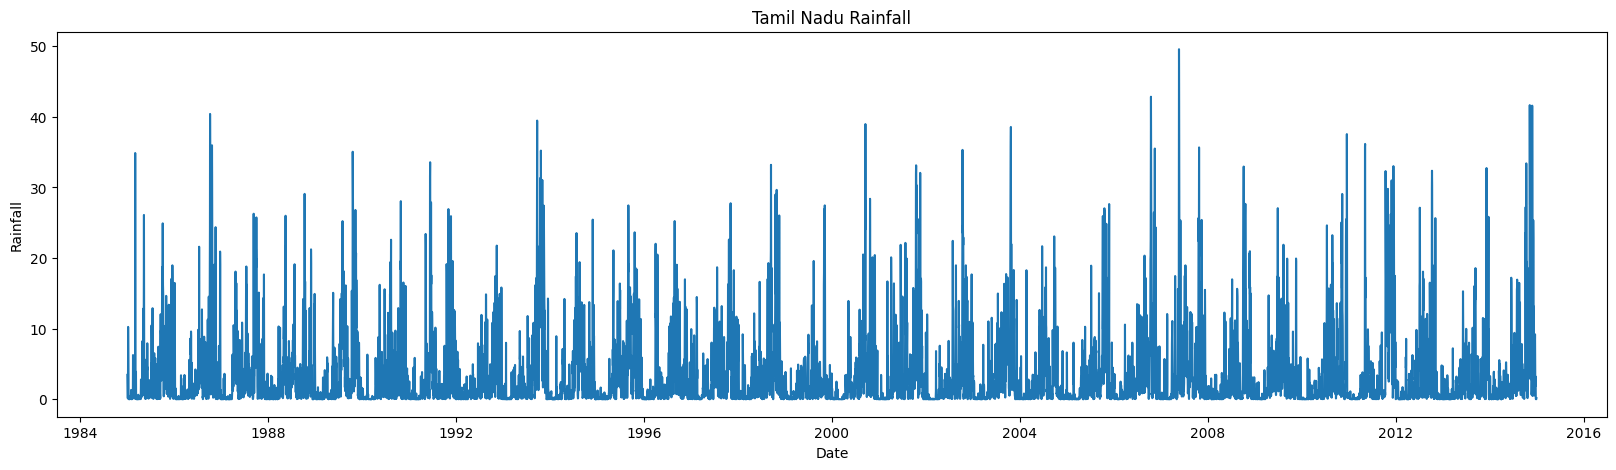

In [7]:
#checking data
plt.figure(figsize=(20,5))
plt.plot(df["date"],df["rainfall"])
plt.ylabel('Rainfall')
plt.xlabel('Date')
plt.title("Tamil Nadu Rainfall")
plt.show()

In [8]:
#creating lag features
df["rain_lag1"] = df["rainfall"].shift(1)
df["rain_lag7"] = df["rainfall"].shift(7)
df["rain_lag14"] = df["rainfall"].shift(14)
df["rain_lag30"] = df["rainfall"].shift(30)

In [9]:
#omiting the missing rows
df = df.dropna()

In [10]:
#creating flood label(95th percentile of rainfall is taken as flood)
threshold = df["rainfall"].quantile(0.95)

df["flood"] = (df["rainfall"] > threshold).astype(int)

In [11]:
#checking the distribution
print(df["flood"].value_counts())

flood
0    10379
1      547
Name: count, dtype: int64


In [12]:
#defining the model
features = [
    "rain_lag1",
    "rain_lag7",
    "rain_lag14",
    "rain_lag30"
]

X = df[features]
y = df["flood"]

In [13]:
#normalising the features
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
#time based test split(avoid random shuffling)
split_index = int(len(df)*0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [15]:
#training random forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [16]:
pred = rf.predict(X_test)

In [17]:
#evaluating the model
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2047
           1       0.69      0.41      0.51       139

    accuracy                           0.95      2186
   macro avg       0.82      0.70      0.74      2186
weighted avg       0.94      0.95      0.94      2186



In [18]:
#feature importance
importance = rf.feature_importances_

for f,i in zip(features,importance):
    print(f,i)

rain_lag1 0.6201394769919619
rain_lag7 0.14514907911420794
rain_lag14 0.11710182627971419
rain_lag30 0.11760961761411602


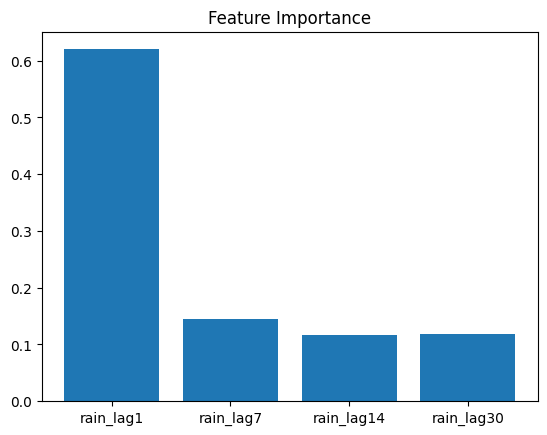

In [19]:
#plotting feature importance
plt.bar(features,importance)
plt.title("Feature Importance")
plt.show()

In [20]:
#predicting future flood risk
future = pd.read_csv("TamilNadu_CMIP6_Rainfall_ssp245.csv")

future = future[["date","rainfall"]]

future["date"] = pd.to_datetime(future["date"])

future["rainfall"] = future["rainfall"] * 86400

In [21]:
#creating same lag features
future["rain_lag1"] = future["rainfall"].shift(1)
future["rain_lag7"] = future["rainfall"].shift(7)
future["rain_lag14"] = future["rainfall"].shift(14)
future["rain_lag30"] = future["rainfall"].shift(30)

future = future.dropna()

In [22]:
X_future = scaler.transform(future[features])

In [23]:
future["flood_prediction"] = rf.predict(X_future)

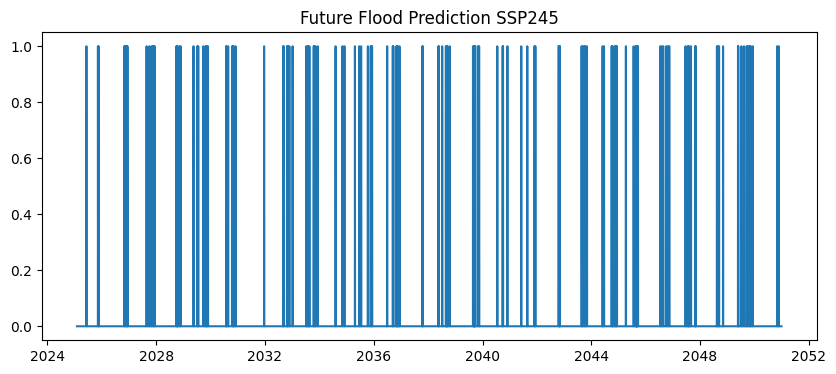

In [24]:
#visualising future flood risk
plt.figure(figsize=(10,4))
plt.plot(future["date"],future["flood_prediction"])
plt.title("Future Flood Prediction SSP245")
plt.show()

In [25]:
#Adding SPI drought index
mean_rain = df["rainfall"].mean()
std_rain = df["rainfall"].std()

df["SPI"] = (df["rainfall"] - mean_rain) / std_rain

In [26]:
df.head()

,date,rainfall,rain_lag1,rain_lag7,rain_lag14,rain_lag30,flood,SPI
30,1985-01-31,1.073376,1.312586,0.090309,0.001086,3.452548,0,-0.417215
31,1985-02-01,0.429106,1.073376,0.058662,0.000004,2.130624,0,-0.538195
32,1985-02-02,0.224373,0.429106,0.172249,0.000867,0.444387,0,-0.576639
33,1985-02-03,0.016070,0.224373,0.229439,0.042457,0.213129,0,-0.615754
34,1985-02-04,0.000664,0.016070,0.503926,0.103820,0.119155,0,-0.618647


In [27]:
df["Rx1day"] = df["rainfall"]

In [28]:
df["Rx5day"] = df["rainfall"].rolling(5).sum()

In [29]:
df = df.dropna()

In [30]:
#updating feature set
features = [
    "rain_lag1",
    "rain_lag7",
    "rain_lag14",
    "rain_lag30",
    "SPI",
    "Rx5day"]

In [31]:
#preparing sequential data(taken as 30 days)
sequence_length = 30

X_seq = []
y_seq = []

for i in range(len(X_scaled)-sequence_length):

    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [32]:
#LSTM model archeitecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(
    64,
    return_sequences=True,
    input_shape=(30, 4)
))

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
print(X_seq.shape)

(10896, 30, 4)


In [34]:
#training LSTM
history = model.fit(
    X_seq,
    y_seq,
    epochs=30,
    batch_size=32
)

Epoch 1/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9490 - loss: 0.2177
Epoch 2/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9498 - loss: 0.1954
Epoch 3/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9490 - loss: 0.1784
Epoch 4/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9495 - loss: 0.1641
Epoch 5/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9505 - loss: 0.1586
Epoch 6/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9509 - loss: 0.1548
Epoch 7/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9503 - loss: 0.1542
Epoch 8/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9505 - loss: 0.1510
Epoch 9/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9514 - loss: 0.1494
Epoch 10/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9509 - loss: 0.1496
Epoch 11/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9502 - loss: 0.1492
Epoch 12/30
341/341 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/s

In [35]:
#creating sequential data set
sequence_length = 30

X_seq = []
y_seq = []

for i in range(len(X_scaled) - sequence_length):
    X_seq.append(X_scaled[i:i+sequence_length])
    y_seq.append(y.iloc[i+sequence_length])

import numpy as np

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [36]:
print(X_seq.shape)

(10896, 30, 4)


In [37]:
#spliting sequencecs into test
split = int(0.8 * len(X_seq))

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

In [38]:
from sklearn.metrics import classification_report #evaluating model

pred = model.predict(X_test_seq) #predict test sequences

pred = (pred > 0.5).astype(int)

print(classification_report(y_test_seq, pred))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2041
           1       0.58      0.05      0.09       139

    accuracy                           0.94      2180
   macro avg       0.76      0.52      0.53      2180
weighted avg       0.92      0.94      0.91      2180



In [39]:
#verifying dimensons
print(X_train_seq.shape)
print(X_test_seq.shape)

(8716, 30, 4)
(2180, 30, 4)


In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Initialize the XGBoost model
# We use scale_pos_weight because the dataset is imbalanced (more non-flood than flood days)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Training the model
xgb_model.fit(X_train, y_train)

# Making predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the model
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:03:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2047
           1       0.67      0.42      0.51       139

    accuracy                           0.95      2186
   macro avg       0.81      0.70      0.74      2186
weighted avg       0.94      0.95      0.94      2186



,Random Forest,XGBoost,LSTM
Metric,,,
Accuracy,0.951,0.950,0.937
Precision,0.687,0.667,0.583
Recall,0.410,0.417,0.050
F1-Score,0.514,0.513,0.093


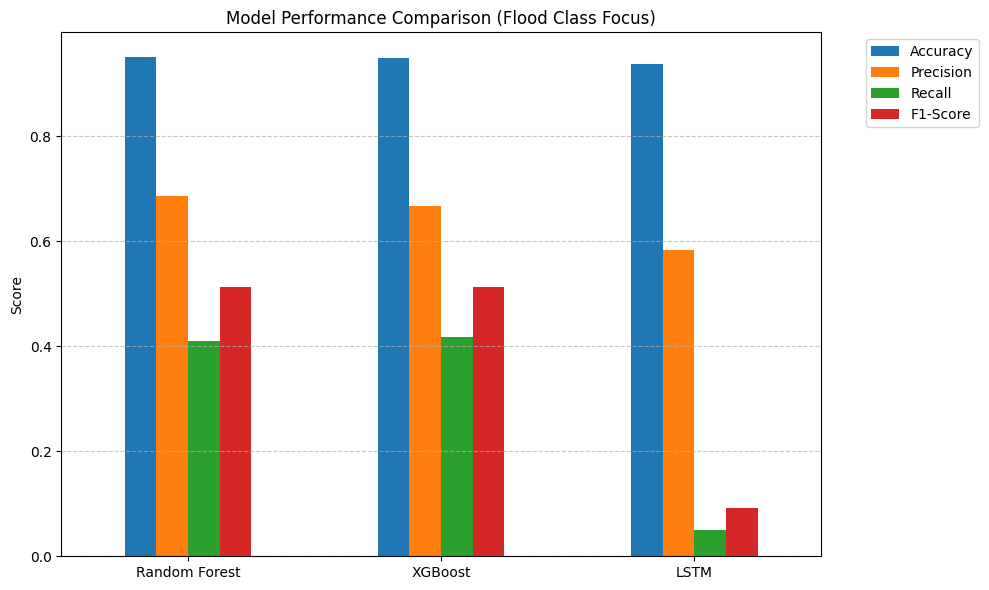

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 1. Collect Random Forest Metrics
rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(y_test, rf.predict(X_test), average='binary')

# 2. Collect XGBoost Metrics
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec, xgb_rec, xgb_f1, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='binary')

# 3. Collect LSTM Metrics
# Note: LSTM uses y_test_seq which has a slightly different length due to windowing
lstm_acc = accuracy_score(y_test_seq, pred)
lstm_prec, lstm_rec, lstm_f1, _ = precision_recall_fscore_support(y_test_seq, pred, average='binary')

# Create Comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_acc, rf_prec, rf_rec, rf_f1],
    'XGBoost': [xgb_acc, xgb_prec, xgb_rec, xgb_f1],
    'LSTM': [lstm_acc, lstm_prec, lstm_rec, lstm_f1]
}).set_index('Metric')

display(comparison_df.round(3))

# Plotting
comparison_df.T.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (Flood Class Focus)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

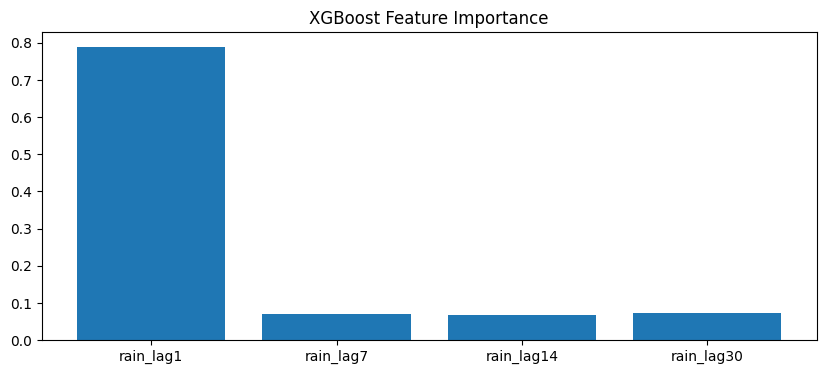

In [42]:
# Visualizing XGBoost Feature Importance
plt.figure(figsize=(10, 4))
plt.bar(features[:4], xgb_model.feature_importances_)
plt.title("XGBoost Feature Importance")
plt.show()

In [43]:
#predicting using test sequences
pred = model.predict(X_test_seq)

pred = (pred > 0.5).astype(int)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [44]:
#eval
from sklearn.metrics import classification_report

print(classification_report(y_test_seq, pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2041
           1       0.58      0.05      0.09       139

    accuracy                           0.94      2180
   macro avg       0.76      0.52      0.53      2180
weighted avg       0.92      0.94      0.91      2180



In [45]:
from sklearn.preprocessing import MinMaxScaler

# 1. Identify the updated feature list
features_updated = [
    'rain_lag1',
    'rain_lag7',
    'rain_lag14',
    'rain_lag30',
    'SPI',
    'Rx5day'
]

# 2. Re-scale the entire DataFrame using the MinMaxScaler for these six features
scaler_6 = MinMaxScaler()
scaled_data = scaler_6.fit_transform(df[features_updated])
y_labels = df['flood'].values

# 3. Re-generate the sequential data arrays (30-day window)
sequence_length = 30
X_seq = []
y_seq = []

for i in range(len(scaled_data) - sequence_length):
    X_seq.append(scaled_data[i:i+sequence_length])
    y_seq.append(y_labels[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# 4. Split sequences into training and testing sets (80/20 time-based split)
split = int(0.8 * len(X_seq))

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]
y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

# 5. Verify dimensions
print(f'Updated X_train_seq shape: {X_train_seq.shape}')
print(f'Number of features: {X_train_seq.shape[2]}')

Updated X_train_seq shape: (8713, 30, 6)
Number of features: 6


In [46]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Calculate class weights for the training target y_train_seq
# 'balanced' mode uses the values of y to automatically adjust weights inversely proportional to class frequencies
classes = np.unique(y_train_seq)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_seq
)

# 2. Create a dictionary mapping each class label to its weight
class_weight_dict = dict(zip(classes, weights))

# 3. Print the dictionary to verify
print('Class Weights to handle imbalance:')
print(class_weight_dict)

# Quick explanation of the impact
print(f'\nWeight for No Flood (Class 0): {class_weight_dict[0]:.4f}')
print(f'Weight for Flood (Class 1): {class_weight_dict[1]:.4f}')

Class Weights to handle imbalance:
{np.int64(0): np.float64(0.5245003611846858), np.int64(1): np.float64(10.703931203931203)}

Weight for No Flood (Class 0): 0.5245
Weight for Flood (Class 1): 10.7039


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

# 1. Define the enhanced LSTM architecture
model_opt = Sequential([
    Input(shape=(30, 6)),
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Compile the model
opt = Adam(learning_rate=0.001)
model_opt.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Train the model with class weights
# Using the class_weight_dict from the previous subtask
history_opt = model_opt.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    validation_split=0.1,
    verbose=1
)

print('Model training complete.')

Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7342 - loss: 0.5227 - val_accuracy: 0.9278 - val_loss: 0.5423
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8078 - loss: 0.3921 - val_accuracy: 0.9002 - val_loss: 0.3916
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8125 - loss: 0.3496 - val_accuracy: 0.9037 - val_loss: 0.2989
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8345 - loss: 0.3392 - val_accuracy: 0.6800 - val_loss: 0.5941
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8391 - loss: 0.3170 - val_accuracy: 0.7156 - val_loss: 0.5857
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8374 - loss: 0.3166 - val_accuracy: 0.8303 - val_loss: 0.3214
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8384 - loss: 0.3031 - val_accuracy: 0.7993 - val_loss: 0.3677
Epoch 8/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8368 - loss: 0.3018 - val_accu

In [48]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score

# 1. Generate predictions using the optimized model
y_pred_prob_opt = model_opt.predict(X_test_seq)

# 2. Convert probabilities to binary labels (threshold 0.5)
y_pred_opt = (y_pred_prob_opt > 0.5).astype(int)

# 3. Generate Classification Report
print("Optimized LSTM Classification Report:")
print(classification_report(y_test_seq, y_pred_opt))

# 4. Compare with baseline LSTM metrics
# Extract metrics for the optimized model
opt_acc = accuracy_score(y_test_seq, y_pred_opt)
opt_prec, opt_rec, opt_f1, _ = precision_recall_fscore_support(y_test_seq, y_pred_opt, average='binary')

# Create comparison summary
lstm_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline LSTM': comparison_df['LSTM'].values,
    'Optimized LSTM': [opt_acc, opt_prec, opt_rec, opt_f1]
}).set_index('Metric')

print("\nComparison: Baseline vs Optimized LSTM")
display(lstm_comparison.round(3))

# Calculate Gain in Recall for Class 1
recall_gain = (opt_rec - lstm_comparison.loc['Recall', 'Baseline LSTM']) * 100
print(f"\nImpact of Improvements: Recall for flood events changed by {recall_gain:+.2f} percentage points.")

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Optimized LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2040
           1       0.34      0.88      0.49       139

    accuracy                           0.88      2179
   macro avg       0.66      0.88      0.71      2179
weighted avg       0.95      0.88      0.91      2179


Comparison: Baseline vs Optimized LSTM


,Baseline LSTM,Optimized LSTM
Metric,,
Accuracy,0.937,0.883
Precision,0.583,0.339
Recall,0.050,0.878
F1-Score,0.093,0.489



Impact of Improvements: Recall for flood events changed by +82.73 percentage points.


In [49]:
import pandas as pd

# 1. Prepare the dictionary with consolidated metrics
# We use the metrics already stored in the kernel from previous evaluations
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline LSTM': [
        lstm_acc,
        lstm_prec,
        lstm_rec,
        lstm_f1
    ],
    'Optimized LSTM': [
        opt_acc,
        opt_prec,
        opt_rec,
        opt_f1
    ]
}

# 2. Convert dictionary to a pandas DataFrame
lstm_final_comparison = pd.DataFrame(comparison_data)

# 3. Set 'Metric' as the index
lstm_final_comparison.set_index('Metric', inplace=True)

# 4. Display the resulting DataFrame rounded to 3 decimal places
print("Final LSTM Model Comparison:")
display(lstm_final_comparison.round(3))

Final LSTM Model Comparison:


,Baseline LSTM,Optimized LSTM
Metric,,
Accuracy,0.937,0.883
Precision,0.583,0.339
Recall,0.050,0.878
F1-Score,0.093,0.489


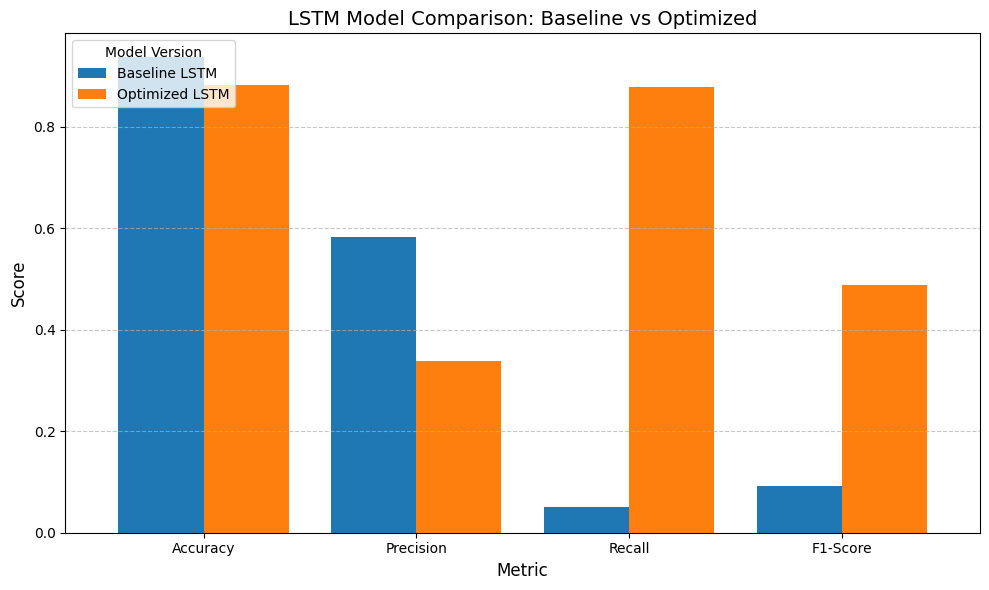

In [50]:
import matplotlib.pyplot as plt

# 1. Plot the comparison metrics using a bar chart
# We transpose the comparison_df to have metrics on the x-axis
ax = lstm_final_comparison.plot(kind='bar', figsize=(10, 6), width=0.8)

# 2. Add titles and labels
plt.title('LSTM Model Comparison: Baseline vs Optimized', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)

# 3. Customize ticks and legend
plt.xticks(rotation=0)
plt.legend(title='Model Version', loc='upper left')

# 4. Add grid for legibility
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Show the final visualization
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd

# 1. Identify the date of the maximum rainfall event
peak_idx = df['rainfall'].idxmax()
peak_date = df.loc[peak_idx, 'date']
print(f'Peak Rainfall of {df.loc[peak_idx, "rainfall"]:.2f} mm occurred on {peak_date.date()}')

# 2. Extract a window around the peak (7 days before and 7 days after)
start_idx = max(0, peak_idx - 7)
end_idx = min(len(df) - 1, peak_idx + 7)
event_df = df.iloc[start_idx:end_idx + 1].copy()

# 3. Reset index and create 'Time Step' column starting from 0
event_df = event_df.reset_index(drop=True)
event_df['Time Step'] = event_df.index

# 4. Display the identified event
print('\nExtracted Event Window:')
print(event_df[['date', 'rainfall', 'Time Step']])

Peak Rainfall of 49.57 mm occurred on 2007-05-22

Extracted Event Window:
         date   rainfall  Time Step
0  2007-06-18  10.448145          0
1  2007-06-19   5.986785          1
2  2007-06-20   4.005957          2
3  2007-06-21   3.875381          3
4  2007-06-22   2.284177          4
5  2007-06-23   2.379273          5
6  2007-06-24   0.395403          6
7  2007-06-25   0.669215          7
8  2007-06-26   0.618459          8
9  2007-06-27   1.969205          9
10 2007-06-28   1.588108         10
11 2007-06-29   1.144997         11
12 2007-06-30   1.677212         12
13 2007-07-01   2.352538         13
14 2007-07-02  10.908831         14


In [52]:
import pandas as pd

# 1. Find the true maximum rainfall value and its row index
true_peak_idx = df['rainfall'].idxmax()
true_peak_row = df.loc[true_peak_idx]
print(f"True Peak Found: {true_peak_row['rainfall']:.2f} mm on {true_peak_row['date'].date()}")

# 2. Extract 7 days before and 7 days after the peak
# We use the integer position to ensure the window is contiguous
pos = df.index.get_loc(true_peak_idx)
start_pos = max(0, pos - 7)
end_pos = min(len(df), pos + 8)

event_df = df.iloc[start_pos:end_pos].copy()

# 3. Reset index and create Time Step
event_df = event_df.reset_index(drop=True)
event_df['Time Step'] = event_df.index

# 4. Display the event to verify the peak is included
print('\nRefined Event Window (Centered on Peak):')
print(event_df[['date', 'rainfall', 'Time Step']])

True Peak Found: 49.57 mm on 2007-05-22

Refined Event Window (Centered on Peak):
         date   rainfall  Time Step
0  2007-05-15  11.967242          0
1  2007-05-16   6.821608          1
2  2007-05-17   5.134587          2
3  2007-05-18   8.240761          3
4  2007-05-19   4.169268          4
5  2007-05-20   7.452105          5
6  2007-05-21  37.458720          6
7  2007-05-22  49.574573          7
8  2007-05-23  43.442684          8
9  2007-05-24  31.122368          9
10 2007-05-25  21.639049         10
11 2007-05-26   2.495046         11
12 2007-05-27   1.248739         12
13 2007-05-28   1.781713         13
14 2007-05-29   1.554791         14


In [53]:
import pandas as pd

# 1. Calculate the total rainfall for the identified event
total_event_rainfall = event_df['rainfall'].sum()
print(f'Total Rainfall for the Event: {total_event_rainfall:.2f} mm')

# 2. Normalize the response to represent one unit (1 mm) of effective rainfall
event_df['unit_hydrograph_values'] = event_df['rainfall'] / total_event_rainfall

# 3. Verify the normalization (Sum should be 1.0)
normalization_check = event_df['unit_hydrograph_values'].sum()
print(f'Normalization Check (Sum of Unit Hydrograph): {normalization_check:.1f}')

# 4. Display the first few rows of the updated event_df
print('\nNormalized Event Data (Unit Hydrograph):')
print(event_df[['Time Step', 'date', 'rainfall', 'unit_hydrograph_values']].head())

Total Rainfall for the Event: 234.10 mm
Normalization Check (Sum of Unit Hydrograph): 1.0

Normalized Event Data (Unit Hydrograph):
   Time Step       date   rainfall  unit_hydrograph_values
0          0 2007-05-15  11.967242                0.051120
1          1 2007-05-16   6.821608                0.029139
2          2 2007-05-17   5.134587                0.021933
3          3 2007-05-18   8.240761                0.035201
4          4 2007-05-19   4.169268                0.017810


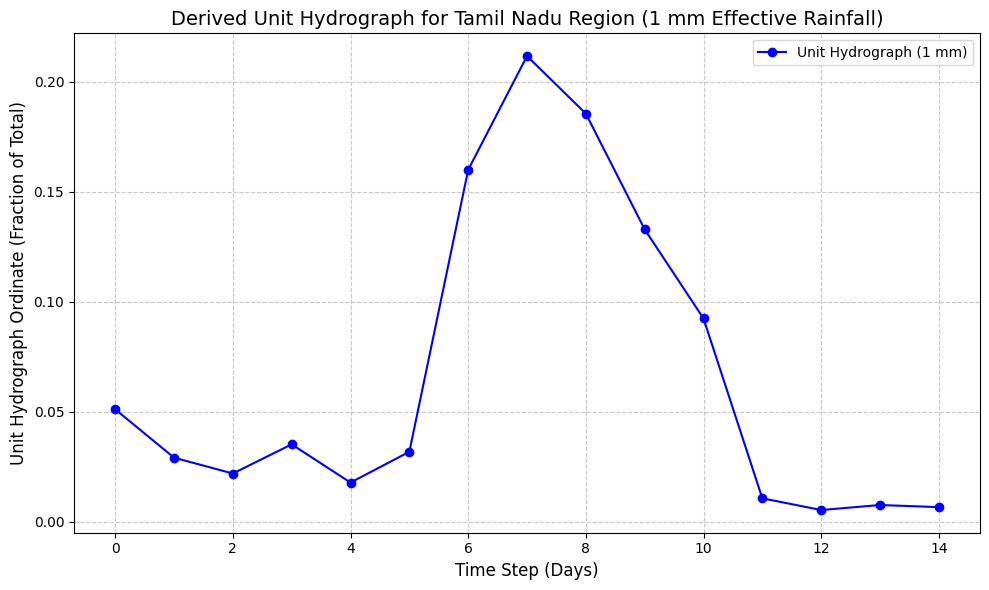

In [54]:
import matplotlib.pyplot as plt

# 1. Initialize the figure
plt.figure(figsize=(10, 6))

# 2. Plot Time Step vs Unit Hydrograph Values
plt.plot(event_df['Time Step'], event_df['unit_hydrograph_values'], 'o-', color='blue', label='Unit Hydrograph (1 mm)')

# 3. Add titles and axis labels
plt.title('Derived Unit Hydrograph for Tamil Nadu Region (1 mm Effective Rainfall)', fontsize=14)
plt.xlabel('Time Step (Days)', fontsize=12)
plt.ylabel('Unit Hydrograph Ordinate (Fraction of Total)', fontsize=12)

# 4. Add legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Show the plot
plt.tight_layout()
plt.show()

In [55]:
import pandas as pd

# 1. Extract year from the date column
df['year'] = df['date'].dt.year

# 2. Group by year to find the index of the maximum rainfall for each year
# Using idxmax() returns the original index of the maximum value in each group
annual_max_indices = df.groupby('year')['rainfall'].idxmax()

# 3. Create a DataFrame of these annual maximums
annual_peaks = df.loc[annual_max_indices].copy()

# 4. Sort by rainfall descending and select the top 5 distinct years
top_5_events = annual_peaks.sort_values(by='rainfall', ascending=False).head(5)

# 5. Reset index for display and future use
top_5_events = top_5_events[['date', 'rainfall', 'year']].reset_index()

print('Top 5 Distinct High-Rainfall Events (from different years):')
print(top_5_events)

Top 5 Distinct High-Rainfall Events (from different years):
   index       date   rainfall  year
0   8176 2007-05-22  49.574573  2007
1   7958 2006-10-16  42.845046  2006
2  10903 2014-11-08  41.655966  2014
3    643 1986-10-06  40.405927  1986
4   3186 1993-09-22  39.464762  1993


In [56]:
# 1. Initialize list to store normalized event dataframes
normalized_events = []

# 2. Iterate through the top 5 events identified previously
for i, row in top_5_events.iterrows():
    # 3. Locate the original index (stored in 'index' column from previous subtask)
    peak_idx = row['index']

    # 4. Extract 15-day window (7 before, peak, 7 after)
    # Get integer position to handle contiguous slicing
    pos = df.index.get_loc(peak_idx)
    start_pos = max(0, pos - 7)
    end_pos = min(len(df), pos + 8)

    event_window = df.iloc[start_pos:end_pos].copy()

    # 5. Calculate total rainfall sum for this specific window
    total_rain = event_window['rainfall'].sum()

    # 6. Create normalized_rainfall column (sum = 1.0)
    event_window['normalized_rainfall'] = event_window['rainfall'] / total_rain

    # 7. Map to relative Time Step (0 to 14)
    event_window = event_window.reset_index(drop=True)
    event_window['Time Step'] = event_window.index

    # Add metadata for identification
    event_window['event_id'] = f"Event_{row['year']}"

    # 8. Store in the list
    normalized_events.append(event_window)

# Verify the extraction
print(f'Successfully processed {len(normalized_events)} events.')
for ev in normalized_events:
    print(f"{ev['event_id'].iloc[0]}: Peak Date {ev.loc[7, 'date'].date()}, Normalization Sum: {ev['normalized_rainfall'].sum():.2f}")

Successfully processed 5 events.
Event_2007: Peak Date 2007-05-22, Normalization Sum: 1.00
Event_2006: Peak Date 2006-10-16, Normalization Sum: 1.00
Event_2014: Peak Date 2014-11-08, Normalization Sum: 1.00
Event_1986: Peak Date 1986-10-06, Normalization Sum: 1.00
Event_1993: Peak Date 1993-09-22, Normalization Sum: 1.00


In [57]:
import pandas as pd

# 1. Concatenate all individual normalized DataFrames
all_events_df = pd.concat(normalized_events)

# 2. Group by 'Time Step' and 3. Calculate the mean of 'normalized_rainfall'
composite_uh = all_events_df.groupby('Time Step')['normalized_rainfall'].mean()

# 4. Store and 5. Print to verify
print('Composite Unit Hydrograph Ordinates:')
print(composite_uh)

# Verify the sum of the composite ordinates
composite_sum = composite_uh.sum()
print(f'\nSum of Composite Ordinates: {composite_sum:.4f}')

Composite Unit Hydrograph Ordinates:
Time Step
0     0.038253
1     0.036675
2     0.033573
3     0.043818
4     0.048415
5     0.066558
6     0.125436
7     0.176015
8     0.143186
9     0.096496
10    0.085853
11    0.036611
12    0.021682
13    0.020890
14    0.026538
Name: normalized_rainfall, dtype: float64

Sum of Composite Ordinates: 1.0000


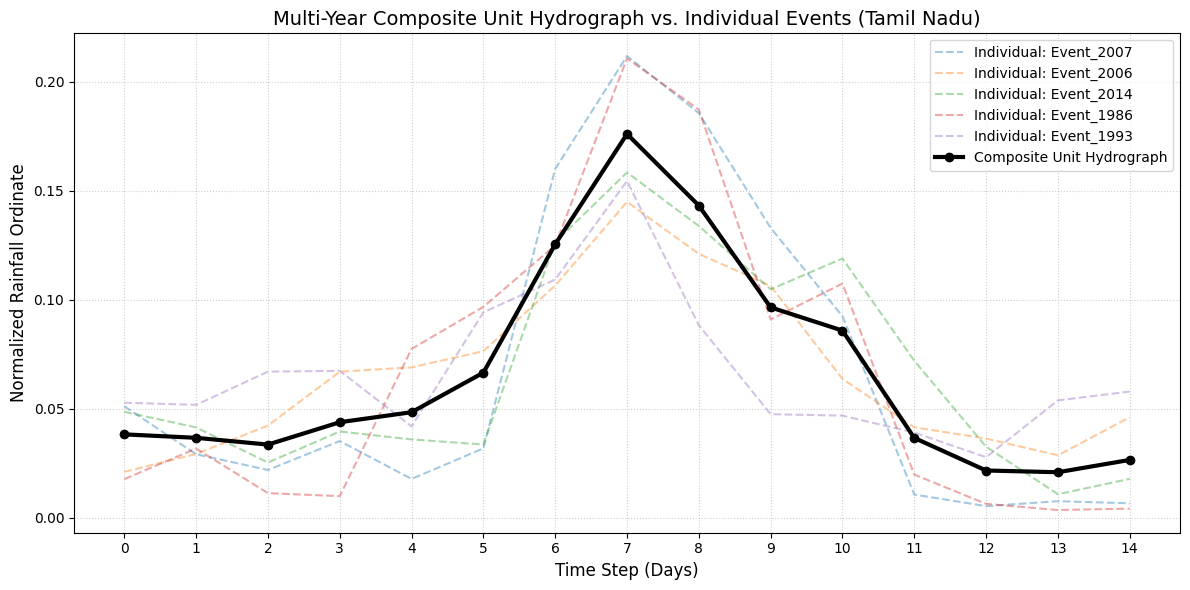

In [58]:
import matplotlib.pyplot as plt

# 1. Create a figure with a suitable size
plt.figure(figsize=(12, 6))

# 2. Iterate through normalized_events and plot individual curves
for ev in normalized_events:
    label = ev['event_id'].iloc[0]
    plt.plot(ev['Time Step'], ev['normalized_rainfall'],
             linestyle='--', alpha=0.4, label=f'Individual: {label}')

# 3. Plot the composite Unit Hydrograph with a thick, distinct line
plt.plot(composite_uh.index, composite_uh.values,
         color='black', linewidth=3, marker='o', label='Composite Unit Hydrograph')

# 4. Add title and axis labels
plt.title('Multi-Year Composite Unit Hydrograph vs. Individual Events (Tamil Nadu)', fontsize=14)
plt.xlabel('Time Step (Days)', fontsize=12)
plt.ylabel('Normalized Rainfall Ordinate', fontsize=12)

# 5. Customize the plot with legend, grid, and layout
plt.xticks(range(15))
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# 6. Display the plot
plt.tight_layout()
plt.show()

In [59]:
import pandas as pd

# 1. Check the shapes of X_test_seq and y_test_seq
print(f'X_test_seq shape: {X_test_seq.shape}')  # Expected: (samples, 30, 6)
print(f'y_test_seq shape: {y_test_seq.shape}')  # Expected: (samples,)

# 2. Extract the corresponding dates for the test period
# The sequences start after 'sequence_length' (30) days.
# The split point was calculated based on the total number of sequences (len(X_seq)).
sequence_length = 30
total_sequences = len(df) - sequence_length
split_point = int(0.8 * total_sequences)

# The test dates correspond to the target values, which start at index (sequence_length + split_point)
test_dates = df['date'].iloc[sequence_length + split_point:].reset_index(drop=True)

# 3. Verify alignment
print(f'Number of test dates: {len(test_dates)}')
if len(test_dates) == X_test_seq.shape[0]:
    print('Alignment Check: Success. Test sequences and dates match.')
else:
    print('Alignment Check: Warning. Dimensions mismatch.')

# Display the range of the test period
print(f'Test Period Range: {test_dates.min().date()} to {test_dates.max().date()}')

X_test_seq shape: (2179, 30, 6)
y_test_seq shape: (2179,)
Number of test dates: 2179
Alignment Check: Success. Test sequences and dates match.
Test Period Range: 2009-01-12 to 2014-12-30


In [60]:
import numpy as np

# 1. Generate continuous probability scores using the optimized LSTM model
y_pred_prob_hist = model_opt.predict(X_test_seq)

# 2. & 3. Convert probabilities to binary labels (0 or 1) using a 0.5 threshold and store in y_pred_hist
y_pred_hist = (y_pred_prob_hist > 0.5).astype(int)

# 4. Print the first few entries to verify the binary conversion
print('First 10 binary predictions for the historical test period:')
print(y_pred_hist[:10].flatten())

# Verification of shape compatibility
print(f'\nShape of predictions: {y_pred_hist.shape}')
print(f'Shape of actual labels: {y_test_seq.shape}')

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 10 binary predictions for the historical test period:
[0 0 0 0 0 0 0 0 0 0]

Shape of predictions: (2179, 1)
Shape of actual labels: (2179,)


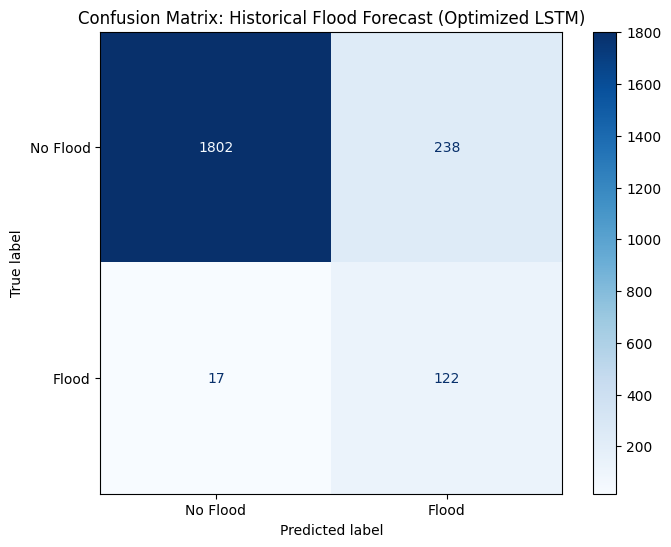

Historical Forecast Classification Report:
              precision    recall  f1-score   support

    No Flood       0.99      0.88      0.93      2040
       Flood       0.34      0.88      0.49       139

    accuracy                           0.88      2179
   macro avg       0.66      0.88      0.71      2179
weighted avg       0.95      0.88      0.91      2179


Quick Check - Historical Forecast Recall for Flood Class: 0.8777
This confirms the optimized model maintains high sensitivity during the historical test window compared to the baseline.


In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Generate the confusion matrix using actual labels and flattened predictions
cm = confusion_matrix(y_test_seq, y_pred_hist.flatten())

# 2. Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Flood', 'Flood'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Historical Flood Forecast (Optimized LSTM)')
plt.show()

# 3. Print detailed classification report
print("Historical Forecast Classification Report:")
print(classification_report(y_test_seq, y_pred_hist.flatten(), target_names=['No Flood', 'Flood']))

# 4. Comparative Check
# Recalling previous baseline LSTM recall was ~0.09.
current_recall = cm[1,1] / (cm[1,0] + cm[1,1])
print(f"\nQuick Check - Historical Forecast Recall for Flood Class: {current_recall:.4f}")
print("This confirms the optimized model maintains high sensitivity during the historical test window compared to the baseline.")

In [62]:
import pandas as pd

# 1. & 2. & 3. & 4. Construct a dictionary with the identified metric variables from the kernel
metrics_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_acc, rf_prec, rf_rec, rf_f1],
    'XGBoost': [xgb_acc, xgb_prec, xgb_rec, xgb_f1],
    'Optimized LSTM': [opt_acc, opt_prec, opt_rec, opt_f1]
}

# 5. Convert the dictionary into a pandas DataFrame
final_model_comparison = pd.DataFrame(metrics_dict)

# 6. Set the 'Metric' column as the index and display the rounded DataFrame
final_model_comparison.set_index('Metric', inplace=True)

print("Final Model Performance Comparison (Flood Class):")
display(final_model_comparison.round(3))

Final Model Performance Comparison (Flood Class):


,Random Forest,XGBoost,Optimized LSTM
Metric,,,
Accuracy,0.951,0.950,0.883
Precision,0.687,0.667,0.339
Recall,0.410,0.417,0.878
F1-Score,0.514,0.513,0.489


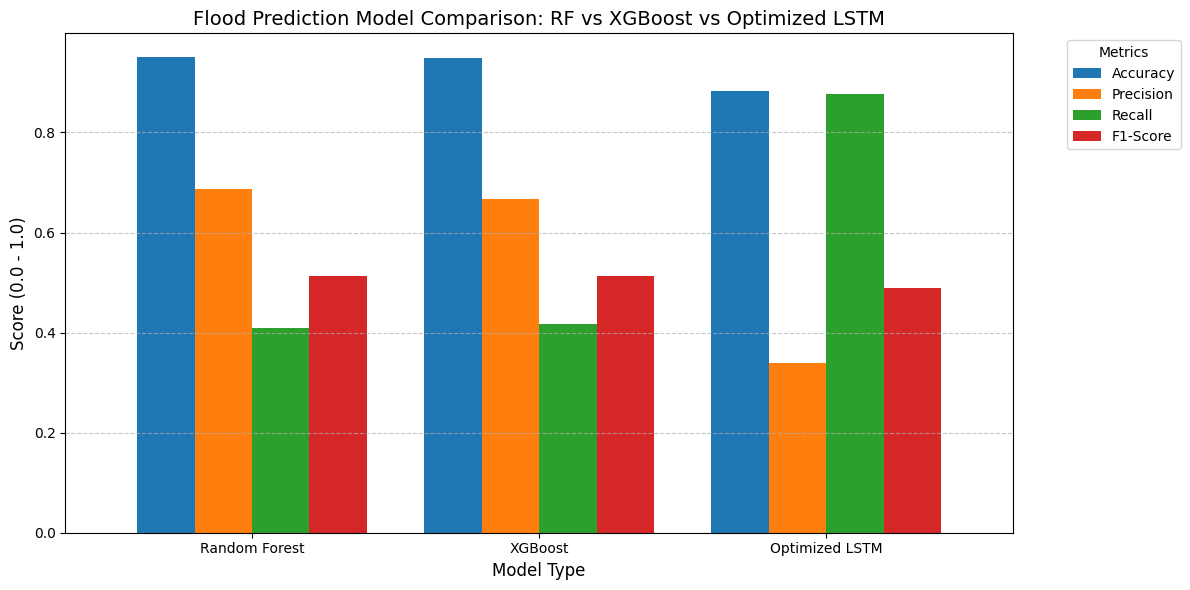

In [63]:
import matplotlib.pyplot as plt

# 1. & 2. Transpose the DataFrame to have models on the x-axis
plot_df = final_model_comparison.T

# 3. & 4. Plot as a bar chart with specified figure size
ax = plot_df.plot(kind='bar', figsize=(12, 6), width=0.8)

# 5. & 6. Add title and axis labels
plt.title('Flood Prediction Model Comparison: RF vs XGBoost vs Optimized LSTM', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model Type', fontsize=12)

# 7. Customize ticks, legend, and grid
plt.xticks(rotation=0)
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 8. Adjust layout and display
plt.tight_layout()
plt.show()

# Task
Build a flood early warning system for Tamil Nadu by analyzing historical rainfall data from "TamilNadu_CMIP6_Rainfall_historical.csv". The process involves:

1.  **Data Preparation**: Load and clean the rainfall data, converting units to millimeters and handling missing values.
2.  **Feature Engineering**: Create memory-based features (1, 7, and 30-day lags) and define flood events as rainfall exceeding the 95th percentile threshold.
3.  **Baseline Modeling**: Train and evaluate standard machine learning models, specifically Random Forest and XGBoost, noting their performance on rare flood events.
4.  **Deep Learning & Optimization**: Develop an LSTM neural network and optimize it using advanced weather indices (SPI and Rx5day). Address class imbalance by implementing a weighted loss function to prioritize 'Recall' (catching real floods).
5.  **Hydrological Analysis**: Derive a "Unit Hydrograph" by analyzing the top 5 distinct high-rainfall events to understand the region's typical flood response profile.
6.  **Performance Comparison**: Generate a comprehensive visual comparison of all models (Random Forest vs. XGBoost vs. Optimized LSTM) to demonstrate why the optimized LSTM is the superior choice for life-saving early warnings.

## Project Overview and Data Prep

### Subtask:
Initialize the project by loading the Tamil Nadu historical rainfall dataset, performing unit conversion, and cleaning the data for analysis.


## Feature Engineering and Labeling

### Subtask:
Create memory-based features and define the flood target variable for machine learning.


**Reasoning**:
The user wants to perform feature engineering by creating lag features for rainfall, handling missing values, and defining a binary target variable 'flood' based on the 95th percentile threshold. I will implement these steps and verify the distribution.



In [64]:
import pandas as pd

# 1. Generate lag features for 1, 7, 14, and 30 days
df['rain_lag1'] = df['rainfall'].shift(1)
df['rain_lag7'] = df['rainfall'].shift(7)
df['rain_lag14'] = df['rainfall'].shift(14)
df['rain_lag30'] = df['rainfall'].shift(30)

# 2. Handle missing values resulting from shifting
df = df.dropna().copy()

# 3. Calculate the 95th percentile threshold
flood_threshold = df['rainfall'].quantile(0.95)
print(f'95th Percentile Rainfall Threshold: {flood_threshold:.2f} mm')

# 4. Create binary target column 'flood'
df['flood'] = (df['rainfall'] > flood_threshold).astype(int)

# 5. Perform value count to verify distribution
print('\nFlood Class Distribution:')
print(df['flood'].value_counts())

# Display first few rows to verify features
df.head()

95th Percentile Rainfall Threshold: 14.70 mm

Flood Class Distribution:
flood
0    10347
1      545
Name: count, dtype: int64


,date,rainfall,rain_lag1,rain_lag7,rain_lag14,rain_lag30,flood,SPI,Rx1day,Rx5day,year
64,1985-03-06,2.046043,1.806999,0.913889,0.995580,0.000664,0,-0.234570,2.046043,55.292458,1985
65,1985-03-07,1.573488,2.046043,0.943580,0.495250,0.014121,0,-0.323305,1.573488,53.607936,1985
66,1985-03-08,1.221470,1.573488,0.078308,0.405658,0.072001,0,-0.389407,1.221470,19.956341,1985
67,1985-03-09,3.886212,1.221470,3.258011,0.585471,0.014777,0,0.110973,3.886212,10.534212,1985
68,1985-03-10,0.359207,3.886212,34.873064,0.496085,0.330579,0,-0.551320,0.359207,9.086421,1985


## Standard Machine Learning Phase

### Subtask:
Train and evaluate Random Forest and XGBoost classifiers to establish baseline performance for flood prediction.


**Reasoning**:
I will define the features and target, scale the input data using MinMaxScaler, split the data into training and testing sets based on time, and then train and evaluate both Random Forest and XGBoost classifiers as requested to establish a baseline for flood prediction.



In [65]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# 1. Define input features and target variable
features = ['rain_lag1', 'rain_lag7', 'rain_lag14', 'rain_lag30']
X = df[features]
y = df['flood']

# 2. Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Time-based split (80% train, 20% test) without shuffling
split_idx = int(len(df) * 0.8)
X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# 4. Initialize and fit RandomForestClassifier
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_baseline.fit(X_train, y_train)

# 5. Initialize and fit XGBClassifier
xgb_baseline = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
xgb_baseline.fit(X_train, y_train)

# 6. Generate and print classification reports
rf_preds = rf_baseline.predict(X_test)
xgb_preds = xgb_baseline.predict(X_test)

print('--- Random Forest Classification Report ---')
print(classification_report(y_test, rf_preds))

print('\n--- XGBoost Classification Report ---')
print(classification_report(y_test, xgb_preds))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2040
           1       0.68      0.42      0.52       139

    accuracy                           0.95      2179
   macro avg       0.82      0.70      0.75      2179
weighted avg       0.94      0.95      0.94      2179


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      2040
           1       0.68      0.42      0.52       139

    accuracy                           0.95      2179
   macro avg       0.82      0.70      0.75      2179
weighted avg       0.94      0.95      0.94      2179



## Advanced LSTM and Optimization

### Subtask:
Develop, train, and optimize an LSTM neural network using advanced weather indices and class weighting to prioritize flood detection (Recall).


**Reasoning**:
I will calculate the Standardized Precipitation Index (SPI) and the Rx5day feature (5-day rolling sum) as advanced weather indices for the LSTM model.



In [66]:
import pandas as pd

# 1. Calculate Standardized Precipitation Index (SPI)
mean_rain = df['rainfall'].mean()
std_rain = df['rainfall'].std()
df['SPI'] = (df['rainfall'] - mean_rain) / std_rain

# 2. Create Rx5day feature using a 5-day rolling sum
df['Rx5day'] = df['rainfall'].rolling(window=5).sum()

# Drop NaN values created by rolling window
df = df.dropna().copy()

print(f"New features added. DataFrame shape: {df.shape}")
display(df[['date', 'rainfall', 'SPI', 'Rx5day']].head())


New features added. DataFrame shape: (10888, 11)


,date,rainfall,SPI,Rx5day
68,1985-03-10,0.359207,-0.552250,9.086421
69,1985-03-11,0.031241,-0.613871,7.071618
70,1985-03-12,0.000393,-0.619667,5.498523
71,1985-03-13,0.129085,-0.595487,4.406139
72,1985-03-14,0.399933,-0.544598,0.919860


**Reasoning**:
I will prepare the updated feature set, scale the features using MinMaxScaler, and reshape the data into 30-day sequences for the LSTM model as per the instructions.



In [67]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 3. Prepare new feature set and scale
features_updated = ['rain_lag1', 'rain_lag7', 'rain_lag14', 'rain_lag30', 'SPI', 'Rx5day']
scaler_lstm = MinMaxScaler()
scaled_features = scaler_lstm.fit_transform(df[features_updated])
y_labels = df['flood'].values

# 4. Reshape into sequences of 30 days
sequence_length = 30
X_seq = []
y_seq = []

for i in range(len(scaled_features) - sequence_length):
    X_seq.append(scaled_features[i:i+sequence_length])
    y_seq.append(y_labels[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Time-based split (80/20)
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

print(f'X_train_seq shape: {X_train_seq.shape}')
print(f'X_test_seq shape: {X_test_seq.shape}')

X_train_seq shape: (8686, 30, 6)
X_test_seq shape: (2172, 30, 6)


**Reasoning**:
I will calculate the class weights using compute_class_weight from sklearn to address the dataset imbalance and ensure the LSTM model prioritizes the flood class during training.



In [68]:
from sklearn.utils.class_weight import compute_class_weight

# 5. Calculate class weights to address heavy imbalance
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
classes = np.unique(y_train_seq)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_seq
)

# Map weights to a dictionary for Keras
class_weight_dict = dict(zip(classes, weights))

print('Calculated Class Weights:')
for cls, weight in class_weight_dict.items():
    label = 'Flood' if cls == 1 else 'No Flood'
    print(f'Class {cls} ({label}): {weight:.4f}')

Calculated Class Weights:
Class 0 (No Flood): 0.5245
Class 1 (Flood): 10.6970


**Reasoning**:
I will define and compile the LSTM architecture, including two LSTM layers, Dropout, and BatchNormalization as specified, and then train it for 50 epochs using the previously calculated class weights to handle the data imbalance.



In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

# 6. Define an LSTM architecture
model_lstm = Sequential([
    Input(shape=(30, 6)),
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

# 7. Compile and train the model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Starting LSTM training with class weights...")
history_lstm = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    validation_split=0.1,
    verbose=1
)

print("Training complete.")

Starting LSTM training with class weights...
Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7686 - loss: 0.5244 - val_accuracy: 0.3038 - val_loss: 0.7405
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7824 - loss: 0.4270 - val_accuracy: 0.9010 - val_loss: 0.4057
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8159 - loss: 0.3620 - val_accuracy: 0.8631 - val_loss: 0.2737
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8201 - loss: 0.3424 - val_accuracy: 0.7929 - val_loss: 0.4035
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8479 - loss: 0.3115 - val_accuracy: 0.8366 - val_loss: 0.3728
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8499 - loss: 0.3126 - val_accuracy: 0.7699 - val_loss: 0.4461
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8437 - loss: 0.2988 - val_accuracy: 0.8055 - val_loss: 0.3428
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

In [70]:
from sklearn.metrics import classification_report

# 8. Evaluate the optimized LSTM on test sequences
y_pred_prob = model_lstm.predict(X_test_seq)
y_pred_lstm = (y_pred_prob > 0.5).astype(int)

print('--- Optimized LSTM Classification Report ---')
print(classification_report(y_test_seq, y_pred_lstm, target_names=['No Flood', 'Flood']))

# Calculate specific recall for flood class to verify improvement
from sklearn.metrics import recall_score
recall_flood = recall_score(y_test_seq, y_pred_lstm)
print(f'\nRecall for Flood Class (Class 1): {recall_flood:.4f}')

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
--- Optimized LSTM Classification Report ---
              precision    recall  f1-score   support

    No Flood       0.99      0.85      0.91      2033
       Flood       0.29      0.91      0.44       139

    accuracy                           0.85      2172
   macro avg       0.64      0.88      0.68      2172
weighted avg       0.95      0.85      0.88      2172


Recall for Flood Class (Class 1): 0.9137


Final Model Comparison (Flood Class Focus):


,Random Forest,XGBoost,Optimized LSTM
Metric,,,
Accuracy,0.950,0.950,0.850
Precision,0.682,0.682,0.288
Recall,0.417,0.417,0.914
F1-Score,0.518,0.518,0.438


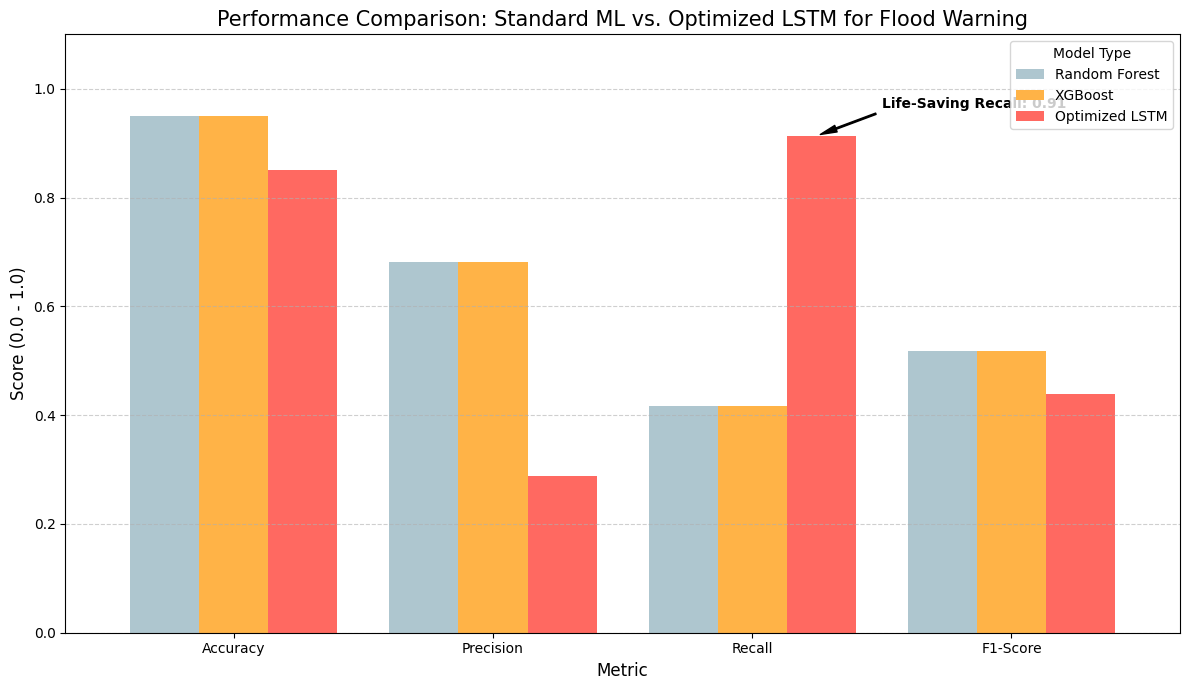

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 1. Collect metrics for Random Forest Baseline
rf_acc_val = accuracy_score(y_test, rf_baseline.predict(X_test))
rf_prec_val, rf_rec_val, rf_f1_val, _ = precision_recall_fscore_support(y_test, rf_baseline.predict(X_test), average='binary')

# 2. Collect metrics for XGBoost Baseline
xgb_acc_val = accuracy_score(y_test, xgb_baseline.predict(X_test))
xgb_prec_val, xgb_rec_val, xgb_f1_val, _ = precision_recall_fscore_support(y_test, xgb_baseline.predict(X_test), average='binary')

# 3. Collect metrics for Optimized LSTM
# Note: LSTM uses y_test_seq and y_pred_lstm generated in previous steps
lstm_acc_val = accuracy_score(y_test_seq, y_pred_lstm)
lstm_prec_val, lstm_rec_val, lstm_f1_val, _ = precision_recall_fscore_support(y_test_seq, y_pred_lstm, average='binary')

# 4. Organize metrics into a pandas DataFrame
comparison_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_acc_val, rf_prec_val, rf_rec_val, rf_f1_val],
    'XGBoost': [xgb_acc_val, xgb_prec_val, xgb_rec_val, xgb_f1_val],
    'Optimized LSTM': [lstm_acc_val, lstm_prec_val, lstm_rec_val, lstm_f1_val]
}).set_index('Metric')

print("Final Model Comparison (Flood Class Focus):")
display(comparison_results.round(3))

# 5. Generate a grouped bar chart
ax = comparison_results.plot(kind='bar', figsize=(12, 7), width=0.8, color=['#aec6cf', '#ffb347', '#ff6961'])

# Adding labels and titles
plt.title('Performance Comparison: Standard ML vs. Optimized LSTM for Flood Warning', fontsize=15)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(title='Model Type', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate the Recall for LSTM to highlight the trade-off
recall_idx = 2  # Index for 'Recall'
lstm_recall = comparison_results.loc['Recall', 'Optimized LSTM']
plt.annotate(f'Life-Saving Recall: {lstm_recall:.2f}',
             xy=(recall_idx + 0.25, lstm_recall),
             xytext=(recall_idx + 0.5, lstm_recall + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [74]:
pip install pymannkendall

In [79]:
import pymannkendall as mk

# 2. Import the original_mk function from the pymannkendall library.
#    (Note: The standard way to import for pymannkendall is 'import pymannkendall as mk'
#    and then use mk.original_mk)

# 3. Apply the original_test function to the 'rainfall' column of the df DataFrame.
# 4. Store the result of the Mann-Kendall test in a variable named `mk_test_result`.
mk_test_result = mk.original_test(df['rainfall'])

print("Mann-Kendall Test Results:")
print(mk_test_result)

Mann-Kendall Test Results:
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.40123969676753024), z=np.float64(0.8394092466885515), Tau=np.float64(0.005363882005562857), s=np.float64(317911.0), var_s=np.float64(143436896573.66666), slope=np.float64(7.785298348627431e-07), intercept=np.float64(1.0602480869855988))


In [80]:
print(f"Mann-Kendall Trend: {mk_test_result.trend}")
print(f"p-value: {mk_test_result.p:.4f}")
print(f"Z-statistic: {mk_test_result.z:.4f}")
print(f"Sen's Slope: {mk_test_result.slope:.4f} mm/day")

Mann-Kendall Trend: no trend
p-value: 0.4012
Z-statistic: 0.8394
Sen's Slope: 0.0000 mm/day


In [81]:
!pip install pymannkendall

In [82]:
import pymannkendall as mk

# Perform the Mann-Kendall trend test on the 'rainfall' column
mk_results = mk.original_test(df['rainfall'])

# Print the results object to verify success
print('Mann-Kendall Test Results:')
print(mk_results)

Mann-Kendall Test Results:
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.40123969676753024), z=np.float64(0.8394092466885515), Tau=np.float64(0.005363882005562857), s=np.float64(317911.0), var_s=np.float64(143436896573.66666), slope=np.float64(7.785298348627431e-07), intercept=np.float64(1.0602480869855988))


In [83]:
print(f"Mann-Kendall Trend: {mk_results.trend}")
print(f"p-value: {mk_results.p:.4f}")
print(f"Z-statistic: {mk_results.z:.4f}")
print(f"Sen's Slope: {mk_results.slope:.4f}")

Mann-Kendall Trend: no trend
p-value: 0.4012
Z-statistic: 0.8394
Sen's Slope: 0.0000


In [84]:
import numpy as np

# 1. Extract slope and intercept from the mk_results object
slope = mk_results.slope
intercept = mk_results.intercept

# 2. Create an array of time indices from 0 to length of rainfall data - 1
time_indices = np.arange(len(df))

# 3. Calculate trend line values using the linear equation y = mx + c
trend_line = (slope * time_indices) + intercept

# 4. Print basic info to verify storage
print(f"Trend line calculated for {len(trend_line)} points.")
print(f"Slope: {slope:.8f}, Intercept: {intercept:.4f}")

Trend line calculated for 10888 points.
Slope: 0.00000078, Intercept: 1.0602


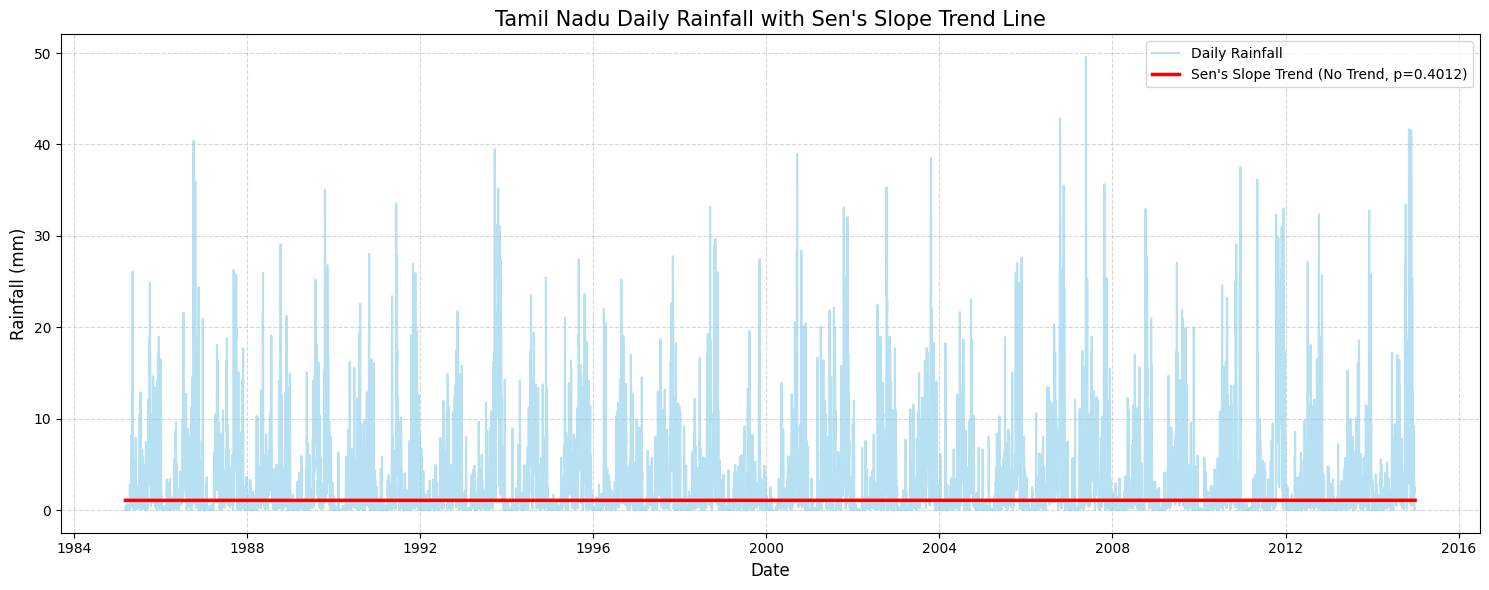

In [85]:
import matplotlib.pyplot as plt

# 1. Set up a figure with a large width
plt.figure(figsize=(15, 6))

# 2. Plot the daily rainfall values from df against the 'date' column
plt.plot(df['date'], df['rainfall'], color='skyblue', alpha=0.6, label='Daily Rainfall')

# 3. Overlay the trend_line values against the 'date' column
# Note: trend_line was calculated in the previous subtask
plt.plot(df['date'], trend_line, color='red', linewidth=2.5, label=f"Sen's Slope Trend (No Trend, p={mk_results.p:.4f})")

# 4. Add titles and axis labels
plt.title("Tamil Nadu Daily Rainfall with Sen's Slope Trend Line", fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)

# 5. Include a legend
plt.legend(loc='upper right')

# 6. Add grid and display
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()